## Memory Types

### Semantic memory ：语义记忆
+ stored object : Facts
+ Human example : Things I learned in school
+ Agent Example : Facts about a user

### Episodic memory : 情景记忆
+ stored object : Experiences
+ Human examples : Things I did
+ Agent Example : Past agent action

### Procedural memory : 程序性记忆
+ stored object : Instructions
+ Human examples : Instincts or motor skills
+ Agent Example : Agent system prompt

## Memory stored
### In the hot path
+ in front of the 'response to user' to update memory
+ easy to maintain
+ more complicated

### In the background
+ another process to do this thing and the main process only focus on response to user
+ separate the memory and main function,respond faster

## Course aims
+ apply in the email agent

In [1]:
# Sematic Memory Profile/Collection
# Episodic Memory : Use few shot examples
# Procedural Memory

In [2]:
# Create a basic email assistant
import os

from langchain.agents.middleware import dynamic_prompt
from langchain_core.messages import SystemMessage

api_key = os.environ.get("DEEPSEEK_API_KEY")

In [3]:
profile = {
    "name" : "jiarui",
    "full_name" : "raojiarui",
    "user_profile_background" : "Senior software engineer and also a university student"
}

In [4]:
prompt_instructions = {
    "triage_rules": {
        # 分类规则
        "ignore": "Marketing newsletters, spam emails, mass company announcements",
        "notify": "Team member out sick, build system notifications, project status updates",
        "respond": "Direct questions from team members, meeting requests, critical bug reports",
    },
    "agent_instructions": "Use these tools when appropriate to help manage emails.",
}

In [5]:
# 创建示例邮件
email = {
    "from" : "Alice Smith <alice.smith@company.com>",
    "to" : "John Doe <john.doe@company.com>",
    "subject" : "Quick question about API documentation",
    "body" : """
    Hi John,

    I was reviewing the API documentation for the new authentication service and noticed a few endpoints are missing. Specifically, I'm looking at:

    - /auth/refresh
    - /auth/validate

    Thanks!
    Alice
    """
}

In [6]:
from pydantic import BaseModel, Field
from typing_extensions import TypedDict, Literal, Annotated
from langchain.chat_models import init_chat_model # 需要先下载deepseek的对应包

In [7]:
llm = init_chat_model(
    model="deepseek-v4-flash",
    api_key=api_key,
    base_url="https://api.deepseek.com/",
    extra_body={
        "thinking" :{
            "type" : "disabled"
        }
    },
    temperature=0
)

In [8]:
class Router(BaseModel):
    """Analyze the unread email and route it according to its content"""

    reasoning : str = Field(
        # 语言模型在此生成决策
        description="Step-by-Step reasoning behind the classification."
    )

    classification: Literal["ignore", "respond", "notify"] = Field(
        description="The classification of an email: ignore for irrelevant emails,notify for important information that doesn't need a response,respond for emails that need a reply",
    )

In [9]:
llm_router = llm.with_structured_output(Router)

In [10]:
from prompts import triage_system_prompt, triage_user_prompt

In [11]:
system_prompt = triage_system_prompt.format(
    full_name = profile["full_name"],
    name = profile["name"],
    examples=None,
    user_profile_background=profile["user_profile_background"],
    triage_no=prompt_instructions["triage_rules"]["ignore"],
    triage_notify=prompt_instructions["triage_rules"]["notify"],
    triage_email=prompt_instructions["triage_rules"]["respond"],
)

In [35]:
user_prompt = triage_user_prompt.format(
    author=email["from"],
    to=email["to"],
    subject=email["subject"],
    email_thread=email["body"],
)

In [37]:
print(user_prompt)


Please determine how to handle the below email thread:

From: Alice Smith <alice.smith@company.com>
To: John Doe <john.doe@company.com>
Subject: Quick question about API documentation

    Hi John,

    I was reviewing the API documentation for the new authentication service and noticed a few endpoints are missing. Specifically, I'm looking at:

    - /auth/refresh
    - /auth/validate

    Thanks!
    Alice
    


In [13]:
result = llm_router.invoke(
    [
        {"role" : "system", "content" : system_prompt},
        {"role" : "user", "content" :
         user_prompt}
    ]
)

In [14]:
print(result)

reasoning='This is a direct question from a team member (Alice) about missing API documentation endpoints. It requires a direct response from jiarui to address the question, so it falls into the RESPOND category.' classification='respond'


In [15]:
from langchain_core.tools import tool

In [16]:
@tool # 暂不实现任何逻辑
def write_email(to: str,subject: str,content: str) -> str:
    """Writer and send an email."""
    # Placeholder response - in real app would send email
    # 需要完成发送邮箱的邮箱地址，邮箱主题和邮箱内容
    return f"Email sent to {to} with subject '{subject}'"

In [17]:
@tool
def schedule_meeting(
        attendees : list[str],
        subject : str,
        duration_minutes : int,
        preferred_day : str # 日历会议
) -> str:
    """Schedule a calendar meeting."""
    return f"Meeting '{subject}' scheduled for {preferred_day} with {len(attendees)} attendees"

In [18]:
@tool
def check_calendar_availability(day : str) -> str:
    """Check calendar availability for a given day."""
    return f"Available times on {day}: 9:00 AM, 2:00 PM, 4:00 PM"

In [39]:
print(agent_system_prompt)


< Role >
You are {full_name}'s executive assistant. You are a top-notch executive assistant who cares about {name} performing as well as possible.
</ Role >

< Tools >
You have access to the following tools to help manage {name}'s communications and schedule:

1. write_email(to, subject, content) - Send emails to specified recipients
2. schedule_meeting(attendees, subject, duration_minutes, preferred_day) - Schedule calendar meetings
3. check_calendar_availability(day) - Check available time slots for a given day
</ Tools >

< Instructions >
{instructions}
</ Instructions >



In [63]:
from prompts import agent_system_prompt
from langchain.agents.middleware import dynamic_prompt
from langchain.messages import SystemMessage

# 创建agent_prompt
@dynamic_prompt # 把函数包装成中间件
def create_prompt(state):
    return  SystemMessage( # 在新的包当中可以不用使用该包装
        content=agent_system_prompt.format(
            instructions=prompt_instructions["agent_instructions"],
            **profile # 传入系统参数
        )
    )

type(create_prompt)

langchain.agents.middleware.types.create_prompt

In [64]:
print(agent_system_prompt)


< Role >
You are {full_name}'s executive assistant. You are a top-notch executive assistant who cares about {name} performing as well as possible.
</ Role >

< Tools >
You have access to the following tools to help manage {name}'s communications and schedule:

1. write_email(to, subject, content) - Send emails to specified recipients
2. schedule_meeting(attendees, subject, duration_minutes, preferred_day) - Schedule calendar meetings
3. check_calendar_availability(day) - Check available time slots for a given day
</ Tools >

< Instructions >
{instructions}
</ Instructions >



In [65]:
from langchain.agents import create_agent # 创建react_agent

In [66]:
tools = [write_email, schedule_meeting, check_calendar_availability]
agent = create_agent(
    llm,
    tools=tools,
    middleware=[create_prompt],
)

In [67]:
response = agent.invoke(
    {
        "messages":[
            {
                "role": "user",
                "content": "whats my availability for tuesday"
            }
        ]
    }
)

In [68]:
response["messages"][-1].pretty_print()

================================== Ai Message ==================================

Here's your availability for **Tuesday**:

- 9:00 AM
- 2:00 PM
- 4:00 PM

Would you like me to schedule anything during one of these slots?


In [25]:
from langgraph.graph import add_messages

class State(TypedDict):
    email_input : dict # email输入
    messages : Annotated[list, add_messages]

In [26]:
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command
from typing import Literal
from IPython.display import Image, display

In [27]:
# 构建代理
def triage_router(state : State) -> Command[
    Literal["response_agent", "__end__"]
]:
    author = state['email_input']['author']
    to = state['email_input']['to']
    subject = state['email_input']['subject']
    email_thread = state['email_input']['email_thread']

    system_prompt = triage_system_prompt.format(
        full_name = profile["full_name"],
        name=profile["name"],
        user_profile_background=profile["user_profile_background"],
        triage_no=prompt_instructions["triage_rules"]["ignore"],
        triage_notify=prompt_instructions["triage_rules"]["notify"],
        triage_email=prompt_instructions["triage_rules"]["respond"],
        examples=None
    )

    user_prompt = triage_user_prompt.format(
        author=author,
        to=to,
        subject=subject,
        email_thread=email_thread
    )

    result = llm_router.invoke(
        [
            {"role" : "system", "content": system_prompt},
            {"role": "user", "content": user_prompt}
        ]
    )

    # 处理三种可能的结果
    if result.classification == "respond":
        print("📧 Classification: RESPOND - This email requires a response")
        goto = "response_agent"
        update = {
            "messages": [
                {
                    "role": "user",
                    "content": f"Respond to the email {state['email_input']}",
                }
            ]
        }
    elif result.classification == "ignore":
        print("🚫 Classification: IGNORE - This email can be safely ignored")
        update = None
        goto = END
    elif result.classification == "notify":
        # If real life, this would do something else
        print("🔔 Classification: NOTIFY - This email contains important information")
        update = None
        goto = END
    else:
        raise ValueError(f"Invalid classification: {result.classification}")
    return Command(goto=goto, update=update)

In [28]:
email_agent = StateGraph(State)
email_agent = email_agent.add_node(triage_router)
email_agent = email_agent.add_node("response_agent", agent)
email_agent = email_agent.add_edge(START, "triage_router")
email_agent = email_agent.compile()


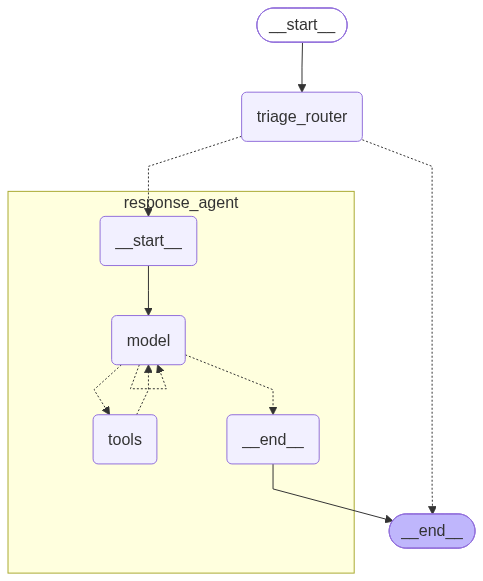

In [29]:
display(Image(email_agent.get_graph(xray=True).draw_mermaid_png()))

In [30]:
email_input = {
    "author": "Marketing Team <marketing@amazingdeals.com>",
    "to": "John Doe <john.doe@company.com>",
    "subject": "🔥 EXCLUSIVE OFFER: Limited Time Discount on Developer Tools! 🔥",
    "email_thread": """Dear Valued Developer,

Don't miss out on this INCREDIBLE opportunity!

🚀 For a LIMITED TIME ONLY, get 80% OFF on our Premium Developer Suite!

✨ FEATURES:
- Revolutionary AI-powered code completion
- Cloud-based development environment
- 24/7 customer support
- And much more!

💰 Regular Price: $999/month
🎉 YOUR SPECIAL PRICE: Just $199/month!

🕒 Hurry! This offer expires in:
24 HOURS ONLY!

Click here to claim your discount: https://amazingdeals.com/special-offer

Best regards,
Marketing Team
---
To unsubscribe, click here
""",
}

In [31]:
response = email_agent.invoke({"email_input": email_input})

🚫 Classification: IGNORE - This email can be safely ignored


In [32]:
email_input = {
    "author": "Alice Smith <alice.smith@company.com>",
    "to": "John Doe <john.doe@company.com>",
    "subject": "Quick question about API documentation",
    "email_thread": """Hi John,

I was reviewing the API documentation for the new authentication service and noticed a few endpoints seem to be missing from the specs. Could you help clarify if this was intentional or if we should update the docs?

Specifically, I'm looking at:
- /auth/refresh
- /auth/validate

Thanks!
Alice""",
}

In [33]:
response = email_agent.invoke({"email_input": email_input})

📧 Classification: RESPOND - This email requires a response


In [34]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Respond to the email {'author': 'Alice Smith <alice.smith@company.com>', 'to': 'John Doe <john.doe@company.com>', 'subject': 'Quick question about API documentation', 'email_thread': "Hi John,\n\nI was reviewing the API documentation for the new authentication service and noticed a few endpoints seem to be missing from the specs. Could you help clarify if this was intentional or if we should update the docs?\n\nSpecifically, I'm looking at:\n- /auth/refresh\n- /auth/validate\n\nThanks!\nAlice"}
================================== Ai Message ==================================

I'll help you respond to this email. Let me first check the context to understand the situation better.

The email is from Alice Smith to John Doe about missing API documentation endpoints. Since you're jiarui's assistant, I should clarify: are you John Doe (jiarui), or should I draft a response on your behalf?

Assuming you are John 